# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Ecommerce INR Dataset](https://www.kaggle.com/datasets/amaymishra11/indian-e-commerce-dataset-inr)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('ecommerce_products_killer.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,product_id,product_name,brand,category,subcategory,price,currency,discount_percent,discounted_price,rating,reviews_count,popularity_score,stock_status,date_added,description
0,P100000,iPhone 13,Apple,Electronics,Smartphone,65372,INR,57,28109.96,3.7,3050,11285.0,Limited Stock,2025-10-17,Apple iPhone 13 is a premium smartphone design...
1,P100001,Zara Shirt,Zara,Fashion,Shirt,2616,INR,55,1177.20,4.1,4699,19265.9,Out of Stock,2026-03-22,Zara Zara Shirt is a premium shirt designed fo...
2,P100002,RayBan Sunglasses,RayBan,Accessories,Sunglasses,1305,INR,58,548.10,3.6,1700,6120.0,In Stock,2025-07-12,RayBan RayBan Sunglasses is a premium sunglass...
3,P100003,Puma Sneakers,Puma,Footwear,Sneakers,7471,INR,60,2988.40,3.5,860,3010.0,In Stock,2026-04-12,Puma Puma Sneakers is a premium sneakers desig...
4,P100004,Nike T-shirt,Nike,Fashion,T-shirt,1305,INR,37,822.15,3.9,138,538.2,Limited Stock,2025-10-30,Nike Nike T-shirt is a premium t-shirt designe...


## last Five row

In [4]:
df.tail()

,product_id,product_name,brand,category,subcategory,price,currency,discount_percent,discounted_price,rating,reviews_count,popularity_score,stock_status,date_added,description
1995,P101995,H&M Sweatshirt,H&M,Fashion,Sweatshirt,3319,INR,62,1261.22,3.8,4201,15963.8,Limited Stock,2024-09-17,H&M H&M Sweatshirt is a premium sweatshirt des...
1996,P101996,Puma Jacket,Puma,Fashion,Jacket,1436,INR,69,445.16,4.0,1580,6320.0,Limited Stock,2024-07-18,Puma Puma Jacket is a premium jacket designed ...
1997,P101997,Dell Laptop,Dell,Electronics,Laptop,63410,INR,66,21559.40,4.0,75,300.0,Out of Stock,2025-03-02,Dell Dell Laptop is a premium laptop designed ...
1998,P101998,H&M Sweatshirt,H&M,Fashion,Sweatshirt,914,INR,20,731.20,5.0,2863,14315.0,Out of Stock,2024-07-19,H&M H&M Sweatshirt is a premium sweatshirt des...
1999,P101999,Puma Sneakers,Puma,Footwear,Sneakers,8941,INR,14,7689.26,4.4,4223,18581.2,In Stock,2024-07-16,Puma Puma Sneakers is a premium sneakers desig...


## Shape of our dataset

In [5]:
df.shape

(2000, 15)

## List out all columns

In [6]:
df.columns

Index(['product_id', 'product_name', 'brand', 'category', 'subcategory',
       'price', 'currency', 'discount_percent', 'discounted_price', 'rating',
       'reviews_count', 'popularity_score', 'stock_status', 'date_added',
       'description'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

product_id           object
product_name         object
brand                object
category             object
subcategory          object
price                 int64
currency             object
discount_percent      int64
discounted_price    float64
rating              float64
reviews_count         int64
popularity_score    float64
stock_status         object
date_added           object
description          object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   product_id        2000 non-null   object 
 1   product_name      2000 non-null   object 
 2   brand             2000 non-null   object 
 3   category          2000 non-null   object 
 4   subcategory       2000 non-null   object 
 5   price             2000 non-null   int64  
 6   currency          2000 non-null   object 
 7   discount_percent  2000 non-null   int64  
 8   discounted_price  2000 non-null   float64
 9   rating            2000 non-null   float64
 10  reviews_count     2000 non-null   int64  
 11  popularity_score  2000 non-null   float64
 12  stock_status      2000 non-null   object 
 13  date_added        2000 non-null   object 
 14  description       2000 non-null   object 
dtypes: float64(3), int64(3), object(9)
memory usage: 234.5+ KB


## Check Null Value

In [9]:
df.isnull().sum()

product_id          0
product_name        0
brand               0
category            0
subcategory         0
price               0
currency            0
discount_percent    0
discounted_price    0
rating              0
reviews_count       0
popularity_score    0
stock_status        0
date_added          0
description         0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,price,discount_percent,discounted_price,rating,reviews_count,popularity_score
count,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,14561.3050,38.565000,8799.172815,4.102250,2519.978000,10364.603250
std,20867.1313,18.966988,13322.938960,0.516888,1435.101165,6120.045918
min,329.0000,5.000000,127.500000,3.200000,10.000000,49.000000
25%,2756.7500,22.000000,1546.402500,3.700000,1281.750000,5158.625000
50%,4739.0000,39.000000,2868.680000,4.100000,2546.000000,10376.650000
75%,9963.7500,56.000000,7513.560000,4.500000,3763.000000,15092.825000
max,79998.0000,70.000000,74423.950000,5.000000,5000.000000,24745.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

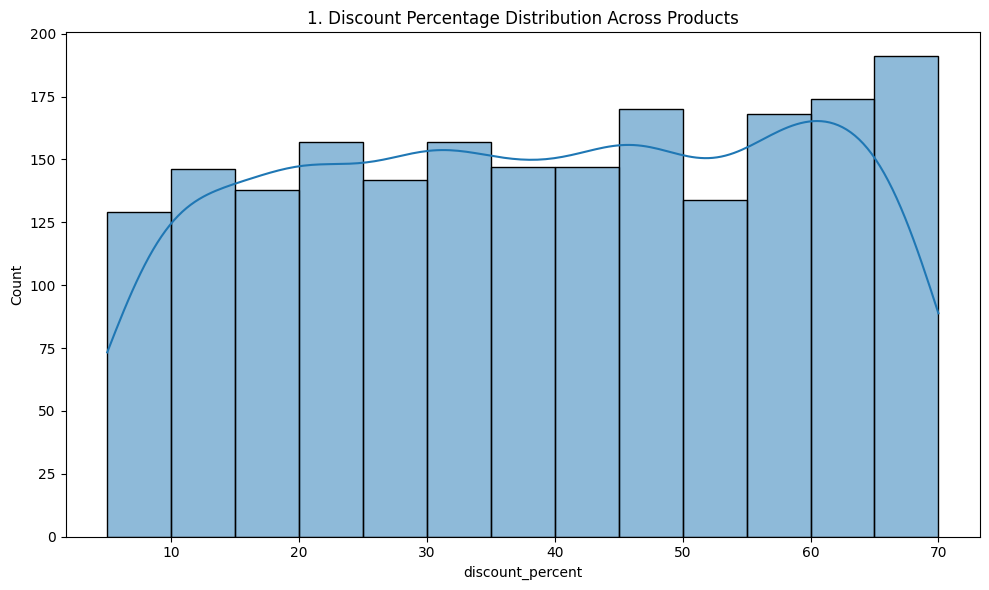

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['discount_percent'], kde=True)
plt.title(f'{plot_no}. Discount Percentage Distribution Across Products')
show_fig()
plot_no += 1

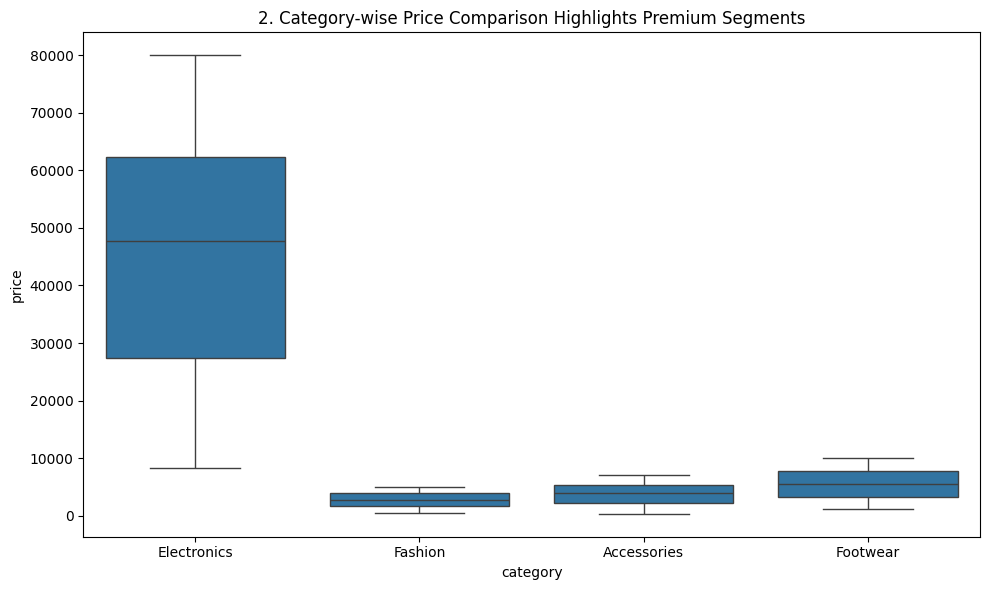

In [14]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='category', y='price', data=df)
plt.title(f'{plot_no}. Category-wise Price Comparison Highlights Premium Segments')
show_fig()
plot_no += 1

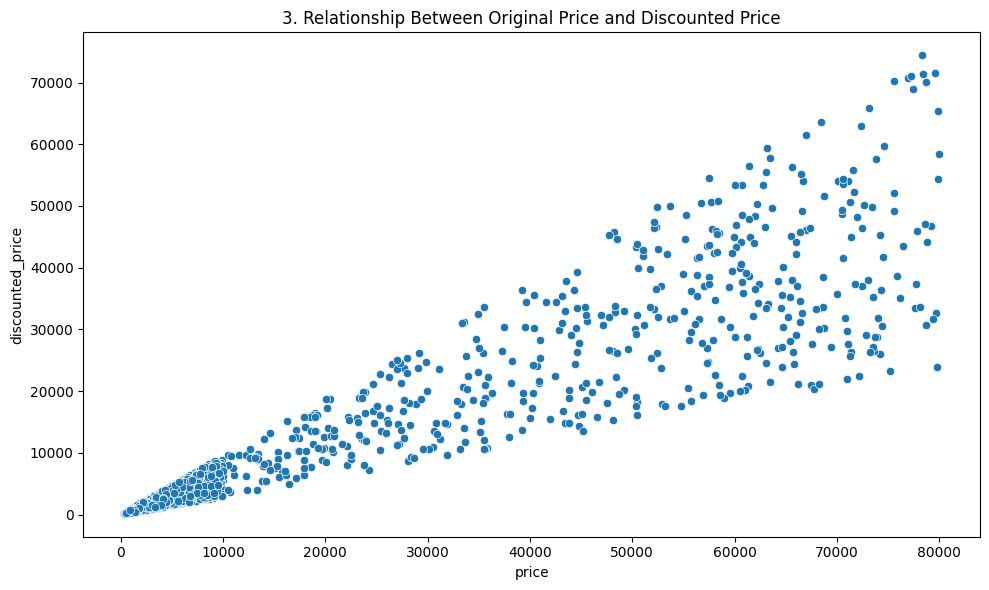

In [15]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='price', y='discounted_price', data=df)
plt.title(f'{plot_no}. Relationship Between Original Price and Discounted Price')
show_fig()
plot_no += 1

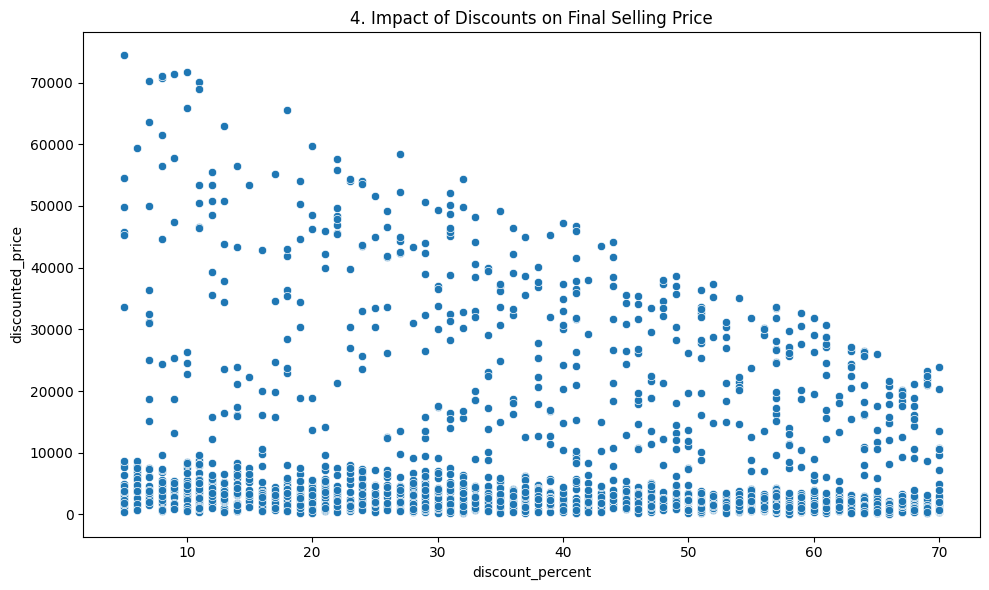

In [16]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='discount_percent', y='discounted_price', data=df)
plt.title(f'{plot_no}. Impact of Discounts on Final Selling Price')
show_fig()
plot_no += 1

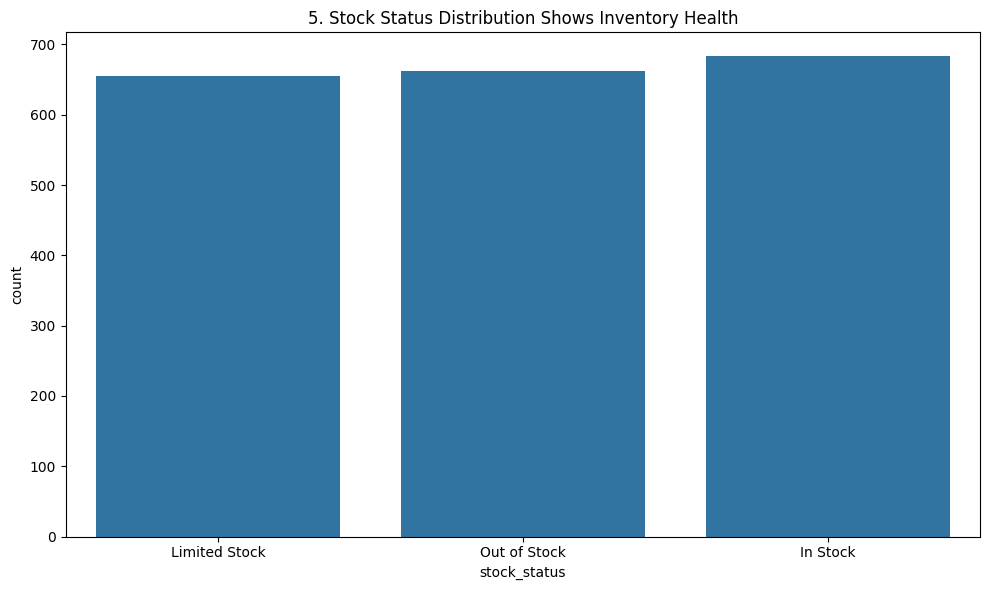

In [17]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='stock_status', data=df)
plt.title(f'{plot_no}. Stock Status Distribution Shows Inventory Health')
show_fig()
plot_no += 1

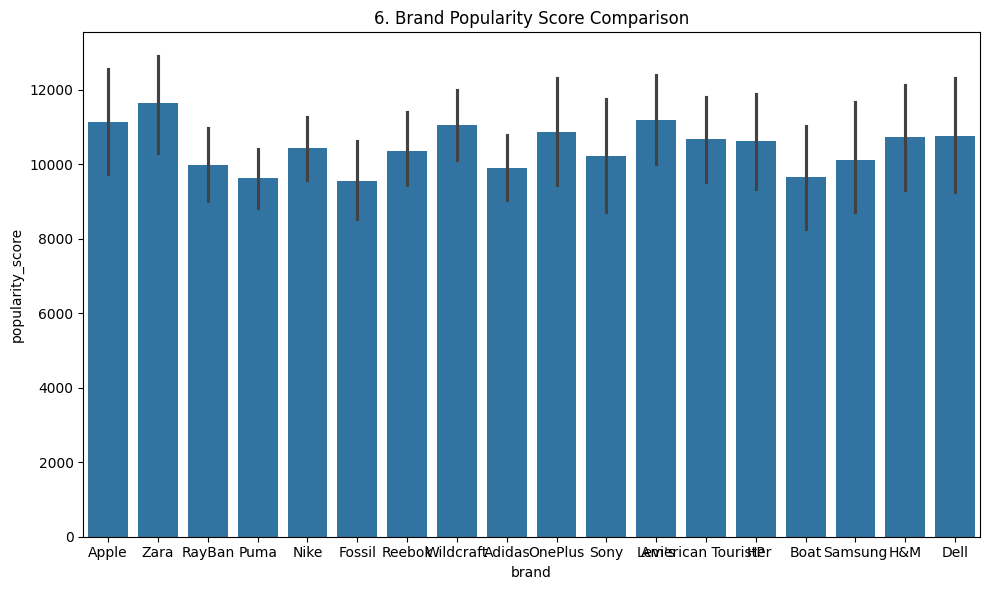

In [18]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='brand', y='popularity_score', data=df)
plt.title(f'{plot_no}. Brand Popularity Score Comparison')
show_fig()
plot_no += 1

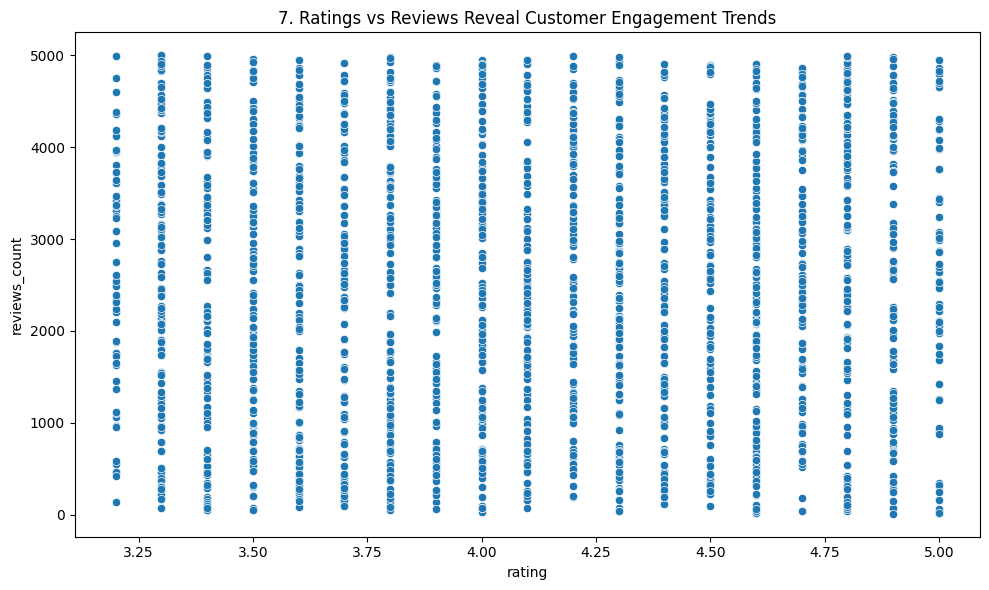

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='rating', y='reviews_count', data=df)
plt.title(f'{plot_no}. Ratings vs Reviews Reveal Customer Engagement Trends')
show_fig()
plot_no += 1

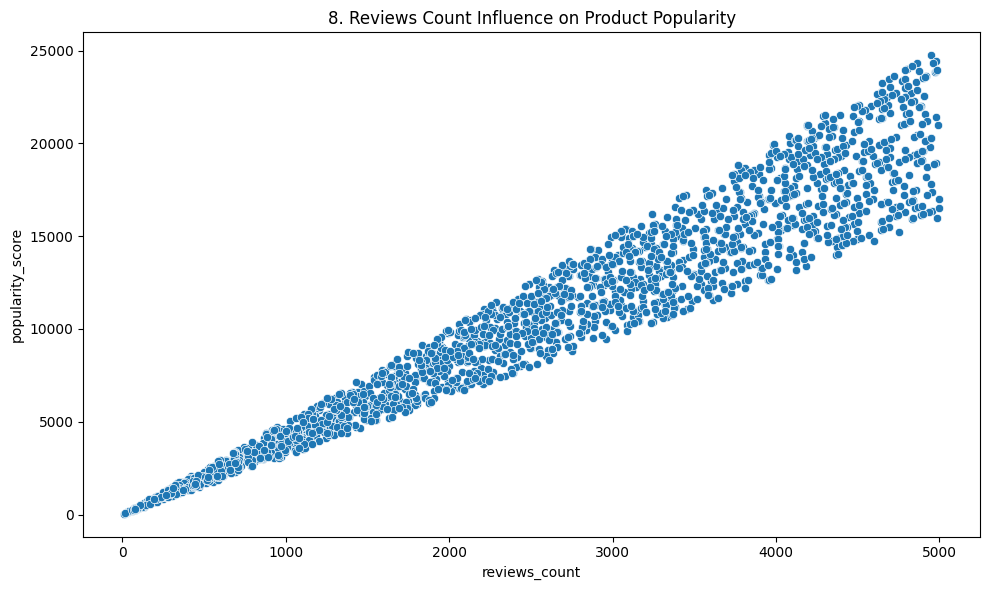

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='reviews_count', y='popularity_score', data=df)
plt.title(f'{plot_no}. Reviews Count Influence on Product Popularity')
show_fig()
plot_no += 1

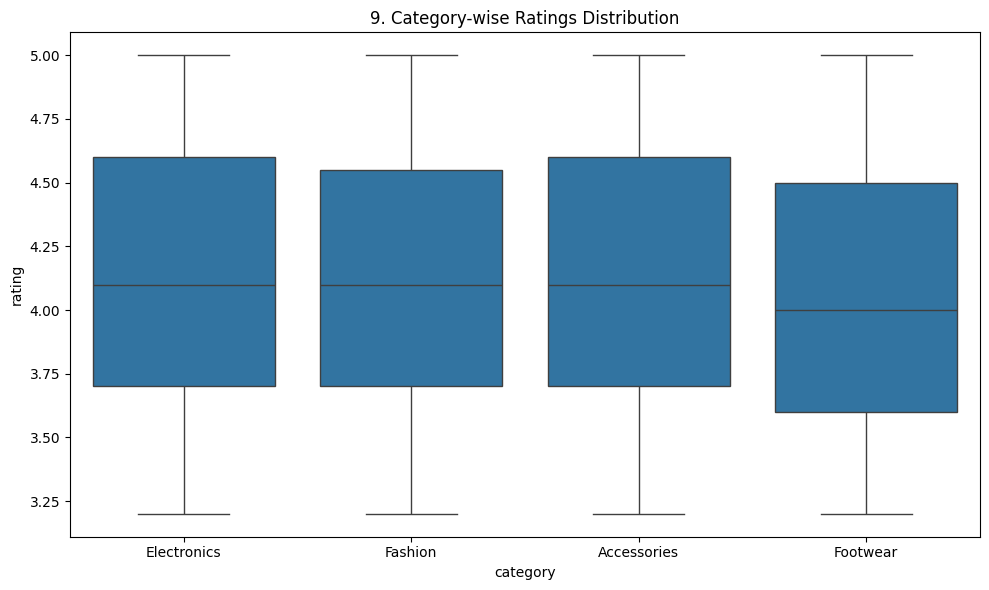

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='category', y='rating', data=df)
plt.title(f'{plot_no}. Category-wise Ratings Distribution')
show_fig()
plot_no += 1

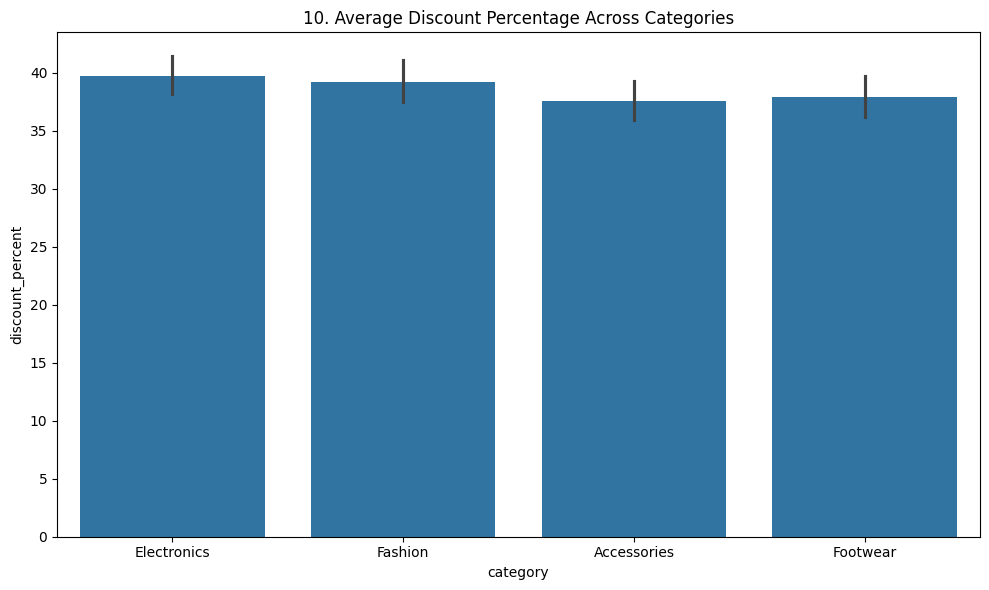

In [22]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='category', y='discount_percent', data=df)
plt.title(f'{plot_no}. Average Discount Percentage Across Categories')
show_fig()
plot_no += 1

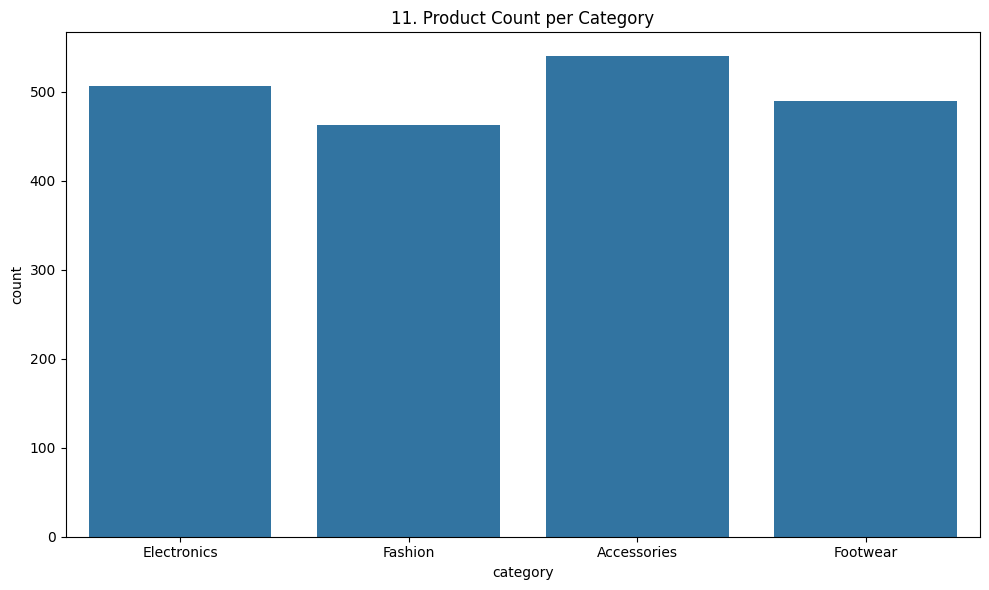

In [23]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='category', data=df)
plt.title(f'{plot_no}. Product Count per Category')
show_fig()
plot_no += 1

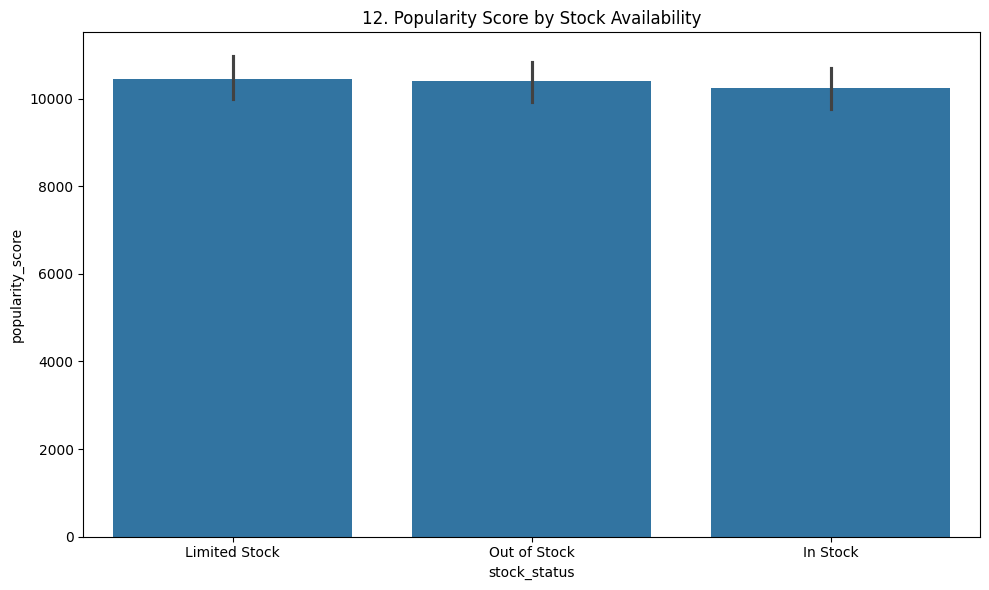

In [24]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='stock_status', y='popularity_score', data=df)
plt.title(f'{plot_no}. Popularity Score by Stock Availability')
show_fig()
plot_no += 1

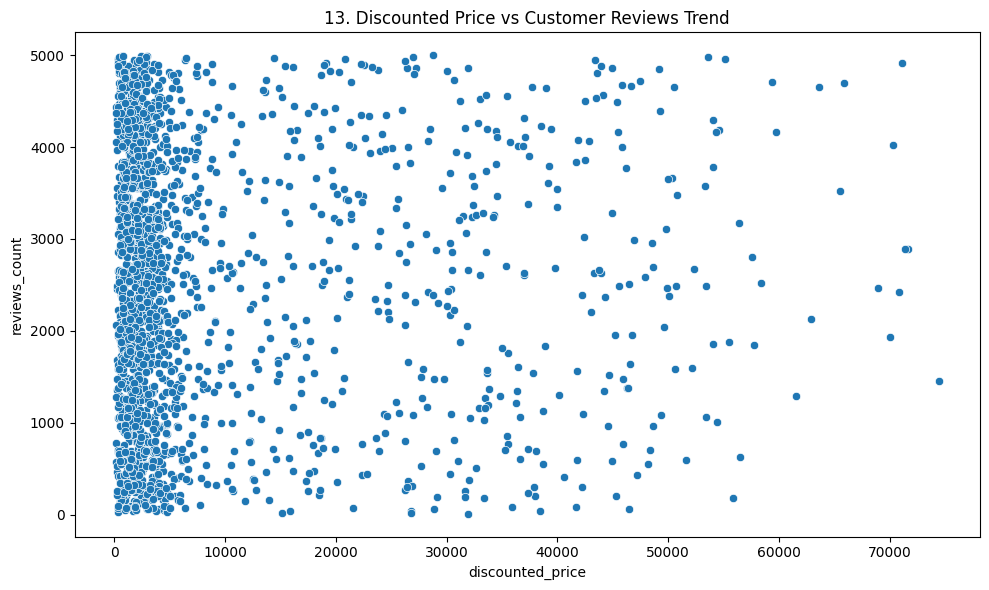

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='discounted_price', y='reviews_count', data=df)
plt.title(f'{plot_no}. Discounted Price vs Customer Reviews Trend')
show_fig()
plot_no += 1

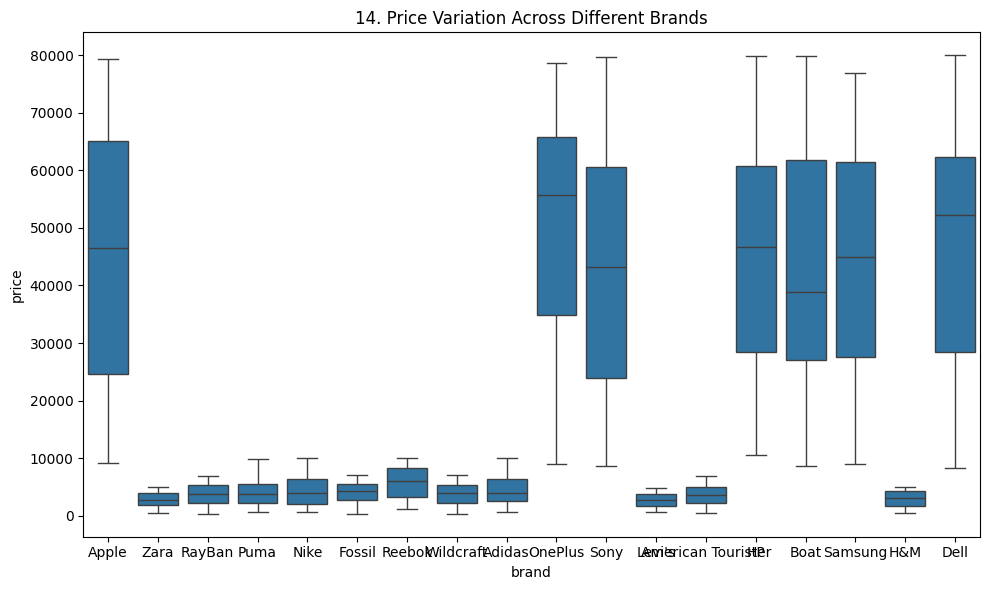

In [26]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='brand', y='price', data=df)
plt.title(f'{plot_no}. Price Variation Across Different Brands')
show_fig()
plot_no += 1

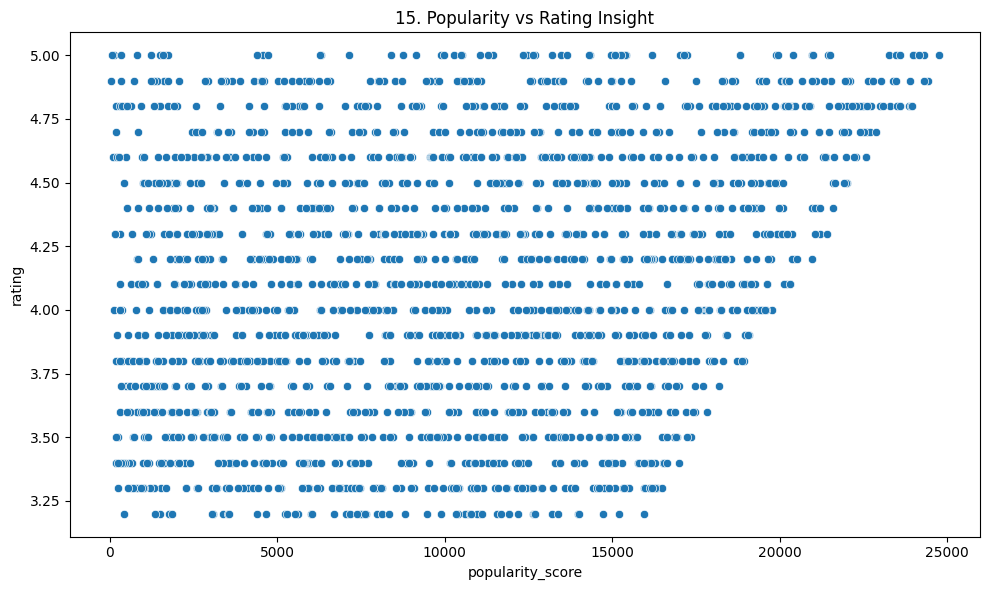

In [27]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='popularity_score', y='rating', data=df)
plt.title(f'{plot_no}. Popularity vs Rating Insight')
show_fig()
plot_no += 1

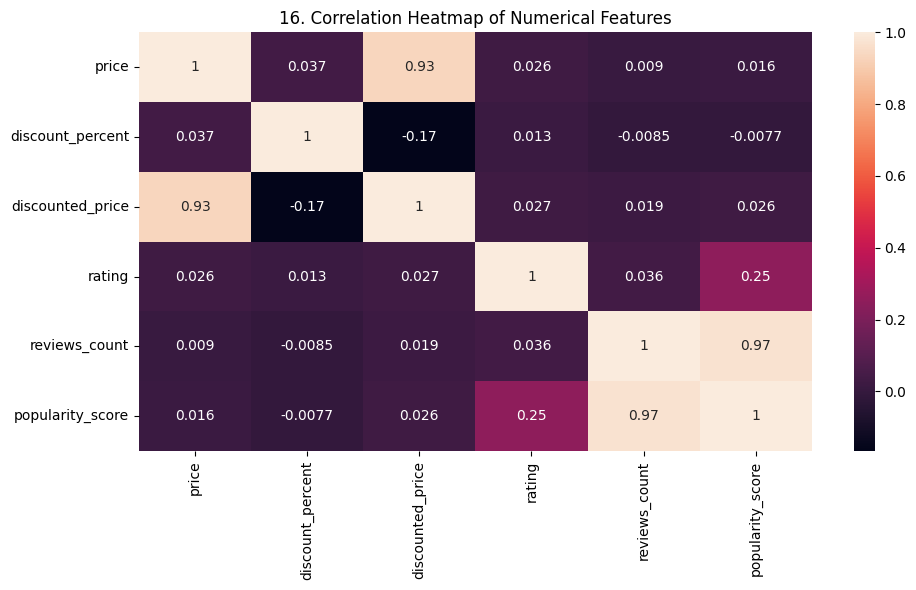

In [28]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include=['int64','float64']).corr()
sns.heatmap(corr, annot=True)
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Features')
show_fig()
plot_no += 1

In [29]:
corr

,price,discount_percent,discounted_price,rating,reviews_count,popularity_score
price,1.000000,0.037050,0.934616,0.026349,0.008973,0.015610
discount_percent,0.037050,1.000000,-0.166415,0.013346,-0.008508,-0.007662
discounted_price,0.934616,-0.166415,1.000000,0.027107,0.018503,0.026284
rating,0.026349,0.013346,0.027107,1.000000,0.036448,0.251425
reviews_count,0.008973,-0.008508,0.018503,0.036448,1.000000,0.968669
popularity_score,0.015610,-0.007662,0.026284,0.251425,0.968669,1.000000


# Model Training

## create target variable

In [30]:
df['target'] = (df['popularity_score'] > df['popularity_score'].median()).astype(int)

## select features and target

In [31]:
X = df[['price', 'discount_percent', 'discounted_price', 'rating', 'reviews_count']]
y = df['target']

## split dataset into train and test

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## apply feature scaling

In [33]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## train model

In [34]:
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## make predictions

In [35]:
y_pred = model.predict(X_test)

## print accuracy score

In [36]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.99


## plot confusion matrix

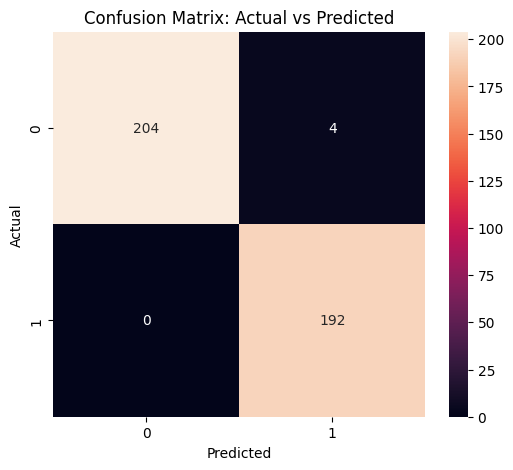

In [37]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix: Actual vs Predicted')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()